Saving svm_farming_datasets.xlsx to svm_farming_datasets (1).xlsx
Dataset Loaded Successfully!

  Sample ID  Soil Nitrogen (mg/kg)  Avg Rainfall (mm)  Class Label    Class
0      W001                  70.83             602.05            1  Healthy
1      W002                  75.15             556.55            1  Healthy
2      W003                  92.58             698.62            1  Healthy
3      W004                  84.47             608.76            1  Healthy
4      W005                  66.91             723.59            1  Healthy

===== Results for C 0.01 =====
Accuracy: 1.0
Confusion Matrix: 
 [[ 9  0]
 [ 0 12]]
Classification Report: 
               precision    recall  f1-score   support

          -1       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21


===== Resu

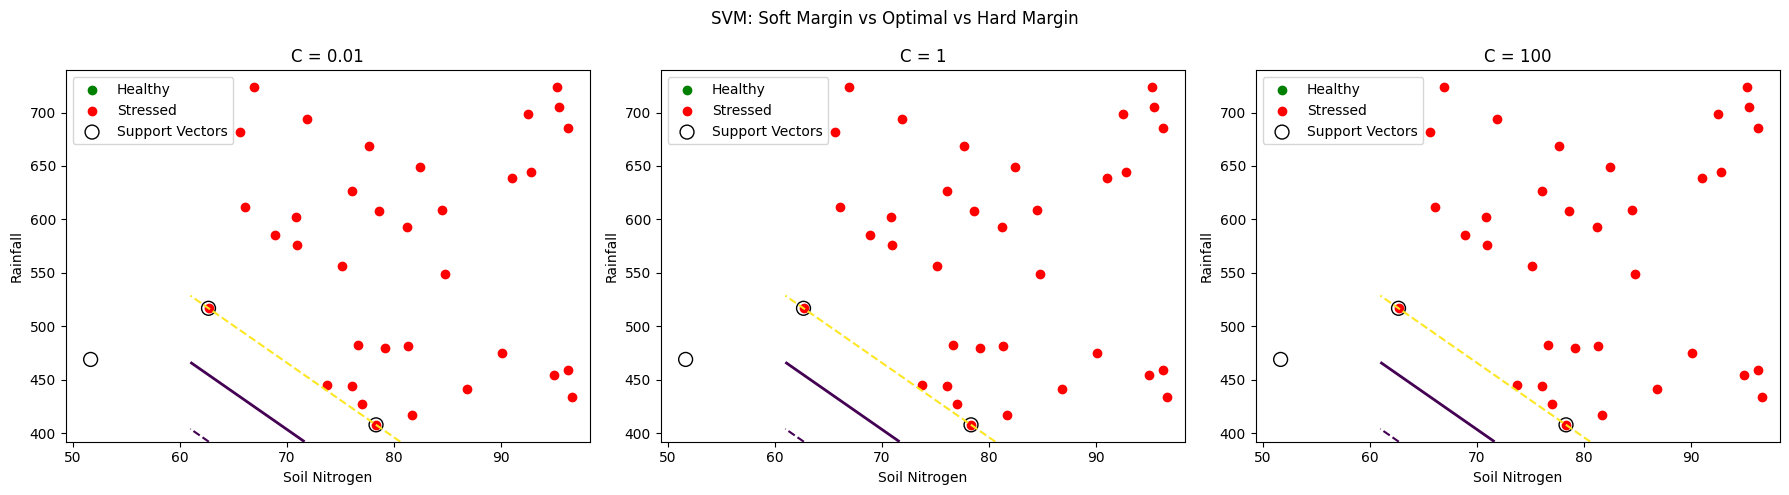

In [9]:
#SVM COMPLETE PIPELINE

#SVM COMPLETE PIPELINE (LOCAL UPLOAD COLAB)

#1. Upload File from Local System

from google.colab import files
uploaded = files.upload()

#Get uploaded file name automatically
file_name = list(uploaded.keys())[0]

#2. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#3. Load Dataset

# FIX: Changed pd.read_csv to pd.read_excel for .xlsx files

df = pd.read_excel(file_name)
print("Dataset Loaded Successfully!\n")
print(df.head())

#4. Clean Column Names (IMPORTANT)

df.columns = df.columns.str.strip()
#Rename Soil Nitrogen and Rainfall columns
df.rename (columns={
"Soil Nitrogen (mg/kg)": "Soil_Nitrogen", "Avg Rainfall (mm)": "Rainfall"
}, inplace=True)

#Drop the 'Sample ID' column as it's not a feature or target
if "Sample ID" in df.columns:
    df.drop(columns=["Sample ID"], inplace=True)

#Ensure the 'Class' column contains numerical labels for the model.

# The original dataset has 'Class Label' (numeric) and possibly 'Class' (string).
# We want to use 'Class Label' for the target variable 'y' and rename it to 'Class'.
# We also need to drop the original string 'Class' column if it exists to avoid ambiguity.
# If both 'Class Label' and 'Class' (string) columns exist, drop the string one first.

if 'Class Label' in df.columns and 'Class' in df.columns:
# Assuming 'Class' is the string column we want to remove based on
# df.head()
    df.drop(columns=['Class'], inplace=True)

#Now, rename 'Class Label' to 'Class' if it exists.
if 'Class Label' in df.columns:
    df.rename(columns={"Class Label": "Class"}, inplace=True)

#5. Features and Labels

X = df[["Soil_Nitrogen", "Rainfall"]]
y = df["Class"] # Now 'Class' is guaranteed to be the numerical 1D series..

#6. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42)

#7. Function: Train + Evaluate + Plot

def train_and_plot(C, subplot_index):
    model = svm.SVC(kernel='linear', C=C)
    model.fit(X_train, y_train)
    #Predictions
    y_pred = model.predict(X_test)
    #Evaluation
    print(f"\n===== Results for C {C} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))
    print("Classification Report: \n", classification_report(y_test,
y_pred))


    # Plotting

    plt.subplot(1, 3, subplot_index)
    #Plot data points
    for label, color in zip([0, 1], ['green', 'red']): # Assuming 0 and 1 are labels, previously zip([1,1]) which is odd.
        subset = df[df["Class"] == label] # 'Class' column now refers to
    #numerical labels

        plt.scatter(subset["Soil_Nitrogen"],
            subset["Rainfall"],
            c=color,
            label=("Healthy" if label == 0 else "Stressed")) # Adjusted label logic
    # Decision boundary
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    XX = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid (yy, XX) # Fixed variable name to XX
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    # Convert xy to a DataFrame with appropriate column names to avoid the UserWarning
    xy_df = pd.DataFrame(xy, columns=X_train.columns)
    Z = model.decision_function(xy_df).reshape(XX.shape)
    # Boundary
    ax.contour (XX, YY, Z, levels=[0], linewidths=2)
    # Margins
    ax.contour (XX, YY, Z, levels=[-1, 1], linestyles=['--', '--'])
    # Support vectors
    ax.scatter (model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=100, facecolors='none',
        edgecolors='black',
        label='Support Vectors')
    plt.xlabel("Soil Nitrogen")
    plt.ylabel("Rainfall")
    plt.title(f"C = {C}")
    plt.legend()

#8. Compare Different C Values

plt.figure(figsize=(18, 5))
C_values = [0.01, 1, 100]

for i, C_val in enumerate (C_values):
    train_and_plot(C_val, i+1)
plt.suptitle("SVM: Soft Margin vs Optimal vs Hard Margin")
plt.tight_layout()
plt.show()